<a href="https://colab.research.google.com/github/CaelMarshall/Crime-Data-in-Leeds-April-2024-GEOG5990M-/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Gen Ai ACknowledgement

I have used Gen AI only for the specific purposes outlined in my acknowledgements

I acknowledge the use of Copilot (Microsoft, https://m365.cloud.microsoft/chat) to
compile my initial notes and to proofread my final draft before submission by the deadline.

In [36]:

#provides the basemaps that can be used underneath spatial outputs
!pip install contextily
#Instalss spatial plotting tools
!pip install geoplot
#Installs features that allow the addition of a north arrow to maps made
!pip install git+https://github.com/pmdscully/geo_northarrow.git
# imports pandas which is used for data manipulation and gives it a shorter alias which is used in further code.
import pandas as pd
#imports numpy for numerical operations and gives it a shorter alias for use in further code
import numpy as np
#Imports geopandas which is used for spatial data and allows the plotting of maps, points and polygons based on
#what the data shows
import geopandas as gpd
# imports matplotlib for plotting graphs and gives it a shorter alias for use in further code. Plt is used to control
#factors such as titles, labels and display functions of graphs
import matplotlib.pyplot as plt
#Used for adding coordinate reference systems and projections
import pyproj
# imports systems used to add basemaps to spatial plots
import contextily as ctx
# imports seaborn which is used to make nicer statistics visualisations and gives it a shorter alias for use
# in further code.
import seaborn as sns
#importsfeatures that allow for spatial plottng
import geoplot as gplt
# imports features that allow for the manipulation of coordinate referance system
import geoplot.crs as gcrs
# imports a function to add a north arrow to the map
from geo_northarrow import add_north_arrow


  Cloning https://github.com/pmdscully/geo_northarrow.git to /tmp/pip-req-build-om1q3jqy
  Running command git clone --filter=blob:none --quiet https://github.com/pmdscully/geo_northarrow.git /tmp/pip-req-build-om1q3jqy
  Resolved https://github.com/pmdscully/geo_northarrow.git to commit c530ad3f9558d05355543e9fe7671f26cd0ffa02
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [39]:
#This code opens up a manual file uplode when running the notebook. By using this code i was able to manualy select
#the crime, imd, and lsoa boundry datasets and upload them manually
from google.colab import files
uploaded = files.upload()
#to check the files have been imported correctly and the data is now prepared for future use
#the following code is used to check the directory and make sure they are present
import os
os.listdir()

Saving IMD_BY_LSOA.csv to IMD_BY_LSOA (1).csv


In [40]:
#this loads the LSOA 2021, IMD and Crime datasets
lsoa = gpd.read_file("LSOA_2021_EW_BGC_V5.shp")
Imd = pd.read_csv("IMD_BY_LSOA.csv")
crime = pd.read_csv("April_Crime_Data.csv")

In [54]:
#This code shows the first 5 rows of both the IMD and Crime datasets
Imd.head()
crime.head()


,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,NaN,2024-04,West Yorkshire Police,West Yorkshire Police,-1.472961,53.599861,On or near Railway Walk,E01007439,Barnsley 001D,Anti-social behaviour,NaN,NaN
1,317bd0abb97f67a9b5e186e9895d13f4fc99d29f2c9f29...,2024-04,West Yorkshire Police,West Yorkshire Police,-1.732999,53.545103,On or near Wood Royd Hill Lane,E01007426,Barnsley 027D,Violence and sexual offences,Unable to prosecute suspect,NaN
2,f3dc2030833b0bc107bc49bfc5182a73b95644e5ed7b3c...,2024-04,West Yorkshire Police,West Yorkshire Police,-1.877569,53.943473,On or near Park Crescent,E01010646,Bradford 001A,Burglary,Investigation complete; no suspect identified,NaN
3,9b7f1084be073130cca59d4dfc1cc1cb7fd7909f7c78bb...,2024-04,West Yorkshire Police,West Yorkshire Police,-1.875348,53.942581,On or near Sycamore Drive,E01010646,Bradford 001A,Criminal damage and arson,Unable to prosecute suspect,NaN
4,e5c5cd14ee4578b58ac1aa079623223e35e48ad173075d...,2024-04,West Yorkshire Police,West Yorkshire Police,-1.882138,53.944232,On or near Parking Area,E01010646,Bradford 001A,Other theft,Investigation complete; no suspect identified,NaN


In [55]:
# shows the coloumn names, data types, and number of non null values in both datasets
Imd.info()
crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33755 entries, 0 to 33754
Data columns (total 56 columns):
 #   Column                                                                                              Non-Null Count  Dtype  
---  ------                                                                                              --------------  -----  
 0   LSOA code (2021)                                                                                    33755 non-null  object 
 1   LSOA name (2021)                                                                                    33755 non-null  object 
 2   Local Authority District code (2024)                                                                33755 non-null  object 
 3   Local Authority District name (2024)                                                                33755 non-null  object 
 4   Index of Multiple Deprivation (IMD) Score                                                           33755 non-nu

In [56]:
#shows the names of the colomns within the IMD dataset
Imd.columns

Index(['LSOA code (2021)', 'LSOA name (2021)',
       'Local Authority District code (2024)',
       'Local Authority District name (2024)',
       'Index of Multiple Deprivation (IMD) Score',
       'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)',
       'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)',
       'Income Score (rate)', 'Income Rank (where 1 is most deprived)',
       'Income Decile (where 1 is most deprived 10% of LSOAs)',
       'Employment Score (rate)', 'Employment Rank (where 1 is most deprived)',
       'Employment Decile (where 1 is most deprived 10% of LSOAs)',
       'Education, Skills and Training Score',
       'Education, Skills and Training Rank (where 1 is most deprived)',
       'Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)',
       'Health Deprivation and Disability Score',
       'Health Deprivation and Disability Rank (where 1 is most deprived)',
       'Health Dep

In [42]:
# # Data downloaded from https://geoportal.statistics.gov.uk/maps/761ecd09b4124843b95511a242e2b1a1
#this code loads the 2021 LSOA boundry shapefile using geopandas and the dataset contains the actual polygon
#data for all LSOAs in England
shp =gpd.read_file('LSOA_2021_EW_BGC_V5.shp')
#to create a subset of just the study area a filter was applied to extract only the LSOAs that had a name containing
#the city 'leeds'
leeds_shp =shp.loc[shp['LSOA21NM'].str.contains('Leeds'),:]
#the filtered dataset is then saved for use in later coding
leeds_shp.to_file('Leeds.geojson')

In [43]:
#this code provides an interactive map preview of the Leeds LSOAs
leeds_shp.explore()

In [44]:
#shows the metadata for the file including number of LSOAs with leeds in their name, the amount of rows and coloums and object type
#for each column
leeds_shp.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 488 entries, 10719 to 33048
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   LSOA21CD   488 non-null    object  
 1   LSOA21NM   488 non-null    object  
 2   LSOA21NMW  0 non-null      object  
 3   BNG_E      488 non-null    int64   
 4   BNG_N      488 non-null    int64   
 5   LAT        488 non-null    float64 
 6   LONG       488 non-null    float64 
 7   GlobalID   488 non-null    object  
 8   geometry   488 non-null    geometry
dtypes: float64(2), geometry(1), int64(2), object(4)
memory usage: 38.1+ KB


In [45]:
#checks the coordinate system of the boundry dataset so that we know what crs to change the other files to
#as they need to match to have correct analysis later
leeds_shp.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

In [46]:
#This block converts the crime dataset from a standard dataframe to a geodataframe and creates
#point geomitries from the longitude and latitude column. This allows the crime data to be spatially aggrigated
#and plotted on the map of leeds later on. It was given a crs of 4326 as this is the universal standard
#when converting gps coordinates
crime_gdf = gpd.GeoDataFrame(
    crime, geometry=gpd.points_from_xy(crime.Longitude, crime.Latitude))
crime_gdf = crime_gdf.set_crs(epsg = 4326)
#the crs of crime data was then reprojected to match that of the Leeds Lsoa which means any spatial joins
#will now be accurate
crime_gdf = crime_gdf.to_crs(leeds_shp.crs)

In [47]:
#This code does a spatial join containing the point data juat made and the polygon boundries of LSOAs
#the 'within' precidate ensures that only the crimes located inside of an LSOA polygon are matched up
crime_lsoa = gpd.sjoin(crime_gdf, leeds_shp, how="inner", predicate="within")

In [48]:
#This block groups the joined datasets by the LSOA code using 'LSOA21CD' with size counting the number of incidents in each area,
#whilst then resenting the result into a clean dataframe with a new column called 'crime count' being added.
#the counts are then merged back into the boundries dataframe so that each LSOA has their associated total
#number of crimes. Finally 'fillna(0)'was used to ensure that LSOAs with no crime records are given a value of 0 instead of just missing
#data all together
crime_counts = crime_lsoa.groupby("LSOA21CD").size().reset_index(name="crime_count")
leeds_shp = leeds_shp.merge(crime_counts, on="LSOA21CD", how= "left")
leeds_shp["crime_count"] = leeds_shp["crime_count"].fillna(0)

In [49]:
#this code merges the IMD dataset to the LSOA dataset which in turn adds deprivation scores to to each LSOA enabling comparison between crime levels
#and socioeconomic conditions
leeds_shp = leeds_shp.merge(Imd, left_on="LSOA21CD", right_on="LSOA code (2021)", how="left")

In [50]:

#This code filters the dataset to identify LSOAs with more than 65 crimes
centre_lsoa=leeds_shp.loc[leeds_shp["crime_count"]> 65,:]

Text(0.5, 1.0, 'Crime Distribution in Leeds')

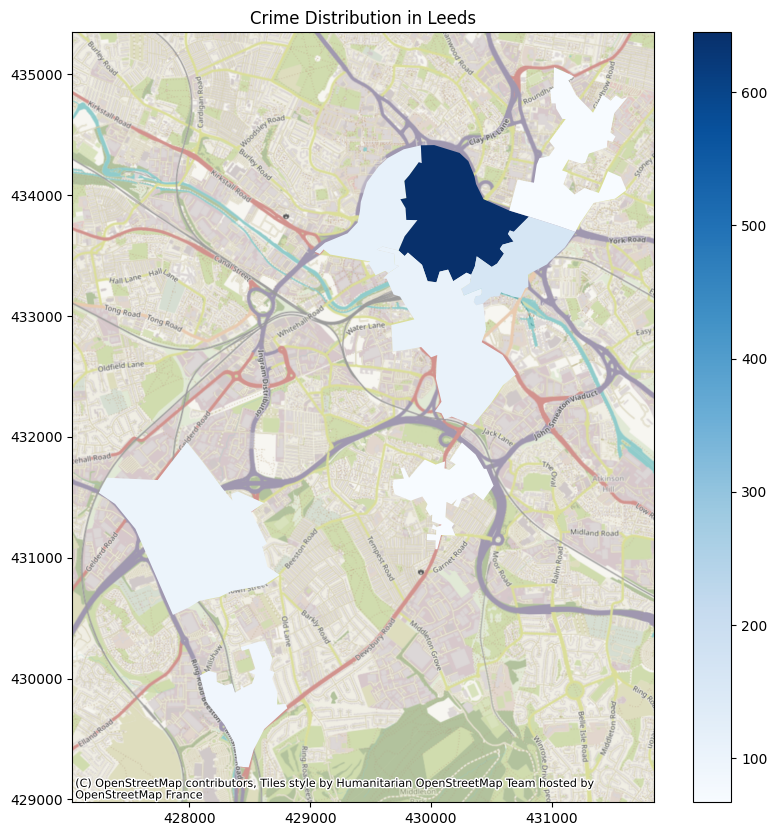

In [51]:
#This block produces a choropleth map with the polygons coloured by crime level, with blue beimg used for the colour
#as it is colourblind friendly and is a sequential colourscheme. The map also has a legend to display the
#colour scale and allows for easy interpritation. A basemap was then added using the same crs as the LSOAs to ensure spatial
#uniformity and context. The map overall highlights the spatial concentration of crime in central Leeds.
f,ax = plt.subplots(1,figsize=(10, 10))
centre_lsoa.plot( ax=ax, column= "crime_count", cmap= "Blues",legend= True )
ctx.add_basemap(ax,crs= leeds_shp.crs)
plt.title("Crime Distribution in Leeds")

Text(0.5, 1.0, 'Crime Distribution in Leeds')

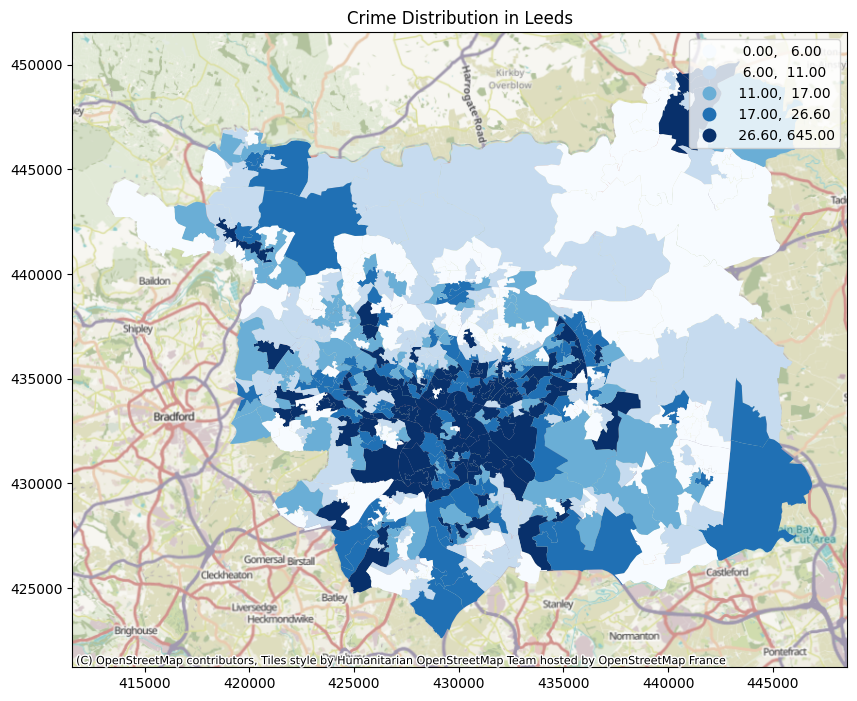

In [52]:
#This block of code visualises crime counts across all the Leeds LSAOs with it being arranged in a quantiles fashion which
#devides the data into five equal sized groups ensuring fair colour distribution.This method is usefull when a dataset
#can be unevenly distributed. The title and basemap here improve readability and comunication for all readers.
f,ax = plt.subplots(1,figsize=(10, 10))
leeds_shp.plot( ax=ax, column= "crime_count", cmap= "Blues",scheme="quantiles",k=5,legend= True )
ctx.add_basemap(ax,crs= leeds_shp.crs)
plt.title("Crime Distribution in Leeds")

/tmp/ipykernel_27123/2812951580.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data= leeds_shp, x="Index of Multiple Deprivation (IMD) Score", y= "crime_count", palette='viridis', marker='o', s=40, alpha=0.7)


Text(0, 0.5, 'Crime Count')

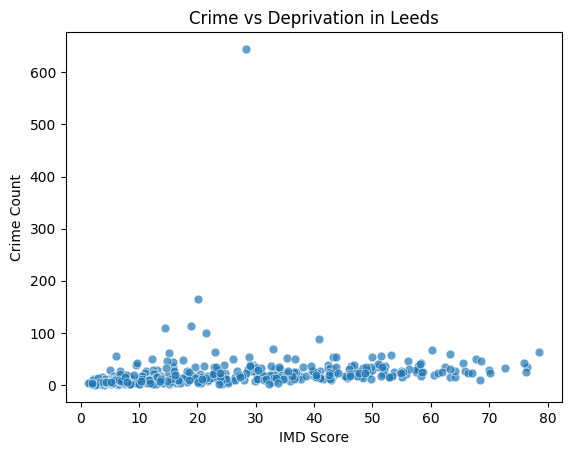

In [53]:
#This scatterplot examines the relationship between crime counts and IMD score for the LSOAs. The use of the 'virdis' pallette makes sure that the colour scheme is
#uniform and clear despite the slight transparency that the individual points have. This visualisation helps identifywhether more deprived areas
#experience higher crime levels.
sns.scatterplot(data= leeds_shp, x="Index of Multiple Deprivation (IMD) Score", y= "crime_count", palette='viridis', marker='o', s=40, alpha=0.7)
plt.title("Crime vs Deprivation in Leeds")
plt.xlabel("IMD Score")
plt.ylabel("Crime Count")